# Imports

In [ ]:
%load_ext autoreload
%autoreload 2

import os

from blockymetamaterials.utils import SolutionData, EigenmodeData, ControlParams, GeometricalParams, LigamentParams, MechanicalParams
from blockymetamaterials.geometry import RotatedSquareGeometry, compute_inertia, DOFsInfo
from blockymetamaterials.energy import build_strain_energy
from blockymetamaterials.analysis_utils import *

import matplotlib.pyplot as plt

import numpy as np
from jax._src.config import config
config.update("jax_enable_x64", True)  # enable float64 type

import scipy, math


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup

In [12]:
# NOTE: Units are mm, N, s → mass in Mg

exp_config = experimental_parameters()

angle30 = 30*np.pi/180                 # dilational case
angle5 = 5*np.pi/180                   # non-dilational case

clamping = True

# Elastic modulii
B30, G1, G2, M30 = RSmoduli(angle30, exp_config['spacing'], exp_config['k_rot'], exp_config['k_stretch'], exp_config['k_shear'], exp_config['hinge_length'])
print(B30,G2,G1,M30)

B5, G1, G2, M5 = RSmoduli(angle5, exp_config['spacing'], exp_config['k_rot'], exp_config['k_stretch'], exp_config['k_shear'], exp_config['hinge_length'])
print(B5,G2,G1,M5)


#Geometry
geometry = RotatedSquareGeometry(n1_cells=exp_config['n1_blocks']//2, n2_cells=exp_config['n2_blocks']//2, spacing=exp_config['spacing'], bond_length=exp_config['hinge_length'])
# centroid_node_vectors is a function of the initial angle
block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()

greenshim_params = MechanicalParams(
        bond_params=LigamentParams(
            reference_vector=reference_bond_vectors(),
            k_stretch=exp_config['k_stretch'],
            k_shear=exp_config['k_shear'],
            k_rot=exp_config['k_rot'],
        ),
        density=exp_config['density'],
    )

print(B30/G2)
print(B5/G2)

0.11049093957559378 0.414705 10.29412 64.9950547764606
3.3031934818596156 0.414705 10.29412 377.9040754628931
0.2664326197552327
7.965164350223932


# Solver

In [13]:
def setup_damped_solver(geometry, potential_energy, control_params, constrained_block_DOF_pairs, free_DOF_ids, new_M, damptype='hinge', damp_coeffs=np.array([]), left=False):
    """ Sets up the damped solver for the given geometry and potential energy.
        Solves the generalized eigenvalue problem for damped dynamics:
                     [ 0      I ] [x]   = λ [ I      0 ] [x]
                     [ -D    -C ] [v]       [ 0      M ] [v]
                 where:
                     D = stiffness matrix
                     C = damping matrix
                     M = mass/inertia matrix
                     x = displacement vector
                     v = velocity vector
                     λ = eigenvalue (i times complex-frequency)
        Expressed as
                     new_D [x v] = λ new_M [x v]
                 where: new_D = [[0, I], [-D, -C]] and new_M = [[I, 0], [0, M]]
    Args:
        geometry: Geometry object defining the lattice structure.
        potential_energy: Function to compute the potential energy of the system.
        control_params: Parameters for the analysis - stiffnesses, density, etc.
        constrained_block_DOF_pairs: List of (block, DOF) pairs that are constrained.
        free_DOF_ids: List of DOF ids that are free (not constrained).
        new_M: new Mass/inertia matrix for first-order system.
        damptype: Type of damping ('hinge' or 'block').
        damp_coeffs: Damping coefficients for the specified damptype.
        left: If True, compute left eigenvectors; otherwise, compute right eigenvectors.
    """

    n1_blocks = geometry.n1_blocks
    n2_blocks = geometry.n2_blocks
    N = n1_blocks*n2_blocks
    print('No. of squares =', N)

    n_free = len(free_DOF_ids)
    print('Total DOFs and free DOFs : ', N*3, n_free )

    state0 = np.zeros((2, geometry.n_blocks, 3)) 

    print('computing matrices') 

    # Force coefficients
    _stiffness, _damping = linear_response_analysis(
        frequencies=np.array([]),
        displacement=state0[0],
        geometry=geometry,
        energy_fn=potential_energy,
        control_params=control_params,
        constrained_block_DOF_pairs=constrained_block_DOF_pairs,
        drive_amplitude=None,
        drive_angle=None,
        driven_block_DOF_pairs=np.array([]),
        return_force_coeffs=True,
        damp_coeffs=damp_coeffs,
        damptype=damptype
    )

    print('matrices computed!')
    
    new_D = np.block(
        [[np.zeros((n_free,n_free),  dtype='double'), np.identity(n_free)],
        [-_stiffness, -_damping]]
    )

    if left is True:
        lams, left_vs, right_vs = scipy.linalg.eig(
            new_D,
            new_M,
            left = True
        )
        say("modes computed!")
        return lams, left_vs, right_vs
    else:
        lams, right_vs = scipy.linalg.eig(
            new_D,
            new_M
        )
        say("modes computed!")
        return lams, right_vs

# Linear modes - experimental size

## Define Clamps

In [14]:
n1 = exp_config['n1_blocks']
n2 = exp_config['n2_blocks']
N = exp_config['N']

if clamping is None:
    clampedblocks = np.array([])
elif clamping is True:
    clampedblocks = np.array([0, 1, n1-2, n1-1, n1, 2*n1-1, N-2*n1, N-n1-1, N-n1, N-n1+1, N-2, N-1])

constrained_block_DOF_pairs = np.array([np.array([block_id, DOF_id]) for DOF_id in range(3) for block_id in clampedblocks])


### Boundary Clamping Diagram

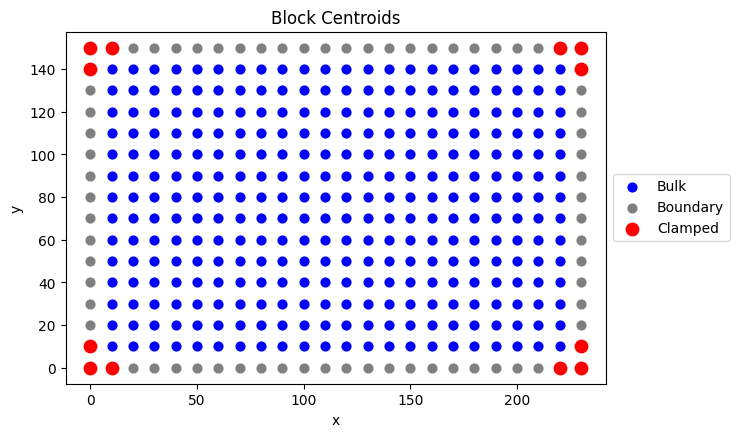

In [15]:
from matplotlib import cm
# from matplotlib.patches import Polygon

fig, ax = plt.subplots(figsize=(8, 6))

# Define centroids from block_centroids at initial_angle
centroids = block_centroids(angle30)                # or angle5, depending on which geometry you want to visualize
centroids_grid = centroids.reshape(n2, n1, 2)

# Create boundary mask: True for boundary (first/last row or column), False for bulk
boundary_mask_grid = np.zeros((n2, n1), dtype=bool)
boundary_mask_grid[0, :] = True
boundary_mask_grid[-1, :] = True
boundary_mask_grid[:, 0] = True
boundary_mask_grid[:, -1] = True

# Flatten for scatter
boundary_mask = boundary_mask_grid.ravel()

# Identify corner block indices in the boundary mask
corner_indices = clampedblocks
# [
#     0, 1, n1,  # top-left: (0,0), (0,1), (1,0)
#     n1-1, n1-2, 2*n1-1,  # top-right: (0,n1-1), (0,n1-2), (1,n1-1)
#     (n2-1)*n1, (n2-1)*n1+1, (n2-2)*n1,  # bottom-left: (n2-1,0), (n2-1,1), (n2-2,0)
#     n2*n1-1, n2*n1-2, n2*n1-1-n1  # bottom-right: (n2-1,n1-1), (n2-1,n1-2), (n2-2,n1-1)
# ]

corner_mask = np.zeros_like(boundary_mask, dtype=bool)
corner_mask[corner_indices] = True

# Scatter bulk, boundary, and corner centroids separately
bulk_mask = ~boundary_mask
boundary_only_mask = boundary_mask & ~corner_mask

ax.scatter(centroids[bulk_mask, 0], centroids[bulk_mask, 1], s=40, color='blue', label='Bulk')
ax.scatter(centroids[boundary_only_mask, 0], centroids[boundary_only_mask, 1], s=40, color='grey', label='Boundary')
ax.scatter(centroids[corner_mask, 0], centroids[corner_mask, 1], s=80, color='red', label='Clamped')


ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Block Centroids')
ax.set_aspect('equal')
# Place legend outside the plot to the right
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.subplots_adjust(right=0.8)  # Make space for legend
plt.show()

## Find Damped Eigenmodes

In [16]:
filename = '../../data/linear_data/linear_damped_eigenmode_analysis'

initial_angle = angle30

# Setup energy function
potential_energy = build_strain_energy(bond_connectivity=bond_connectivity())


# Setup parameters
control_params = ControlParams(
    geometrical_params=GeometricalParams(
        block_centroids=block_centroids(initial_angle),
        centroid_node_vectors=centroid_node_vectors(initial_angle),
        ),
    mechanical_params=greenshim_params,
    )  

free_DOF_ids, constrained_DOF_ids, all_DOF_ids = DOFsInfo(geometry.n_blocks, constrained_block_DOF_pairs)
n_free = len(free_DOF_ids)
n_all = len(all_DOF_ids)

_inertia = compute_inertia(
            vertices=centroid_node_vectors(initial_angle),
            density=exp_config['density']
        ).reshape((geometry.n_blocks * 3,))

new_M = np.block([[np.identity(n_free, dtype='double'), np.zeros((n_free,n_free))],
                  [np.zeros((n_free,n_free)), np.diag(_inertia[free_DOF_ids])]])

In [ ]:
# lams - complex eigenvalues
# right_vs - right eigenvectors |v> with only free DOFs - EIGENMODES WE WANT
# left_vs - left eigenvectors <v| with only free DOFs - DUAL EIGENMODES, USEFUL IN MODE DECOMPOSITION OF INITIAL CONDITIONS AND RESPONSES TO FORCING

damp_coeffs = np.array([exp_config['n_stretch'], exp_config['n_shear'], exp_config['n_rot']])

lams, left_vs, right_vs = setup_damped_solver(geometry, potential_energy, control_params, constrained_block_DOF_pairs,
                    free_DOF_ids, new_M, damp_coeffs=damp_coeffs, left=True)

modes = right_vs.T               # modes[i] is the right eigenmode corresponding to lams[i]
dual_modes = left_vs.T           # dual_modes[i] is the left eigenmode corresponding to lams[i]

# REARRANGE MODES
index = np.argsort(np.abs(lams))            # index for oredering by low to high energy
lams = lams[index]
modes = modes[index]
dual_modes = dual_modes[index]

# ARRANGE MODES INTO FULL SPACE (INCLUDING CONSTRAINED DOFs)
full_modes = np.zeros((2*n_free, 2*n_all), dtype = 'complex_')
full_modes[:, free_DOF_ids] = modes[:,:n_free]                                  # displacement part of modes
full_modes[:, n_all+free_DOF_ids] = modes[:,n_free:]                            # velocity part of modes    

# DUAL MODES ARE ORTHOGONAL TO RIGHT MODES IN THE NEW_M INNER PRODUCT, SUCH THAT <dual_mode[i], new_M @ mode[j]> = 0 FOR i!=j
# NORMALISE DUAL MODES, SUCH THAT <dual_mode[i], new_M @ mode[i]> = 1
orthoamps = np.array([np.vdot(dual_modes[i,:], new_M @ modes[i,:]) for i in range(dual_modes.shape[0])])
print('non-zero inner products', np.count_nonzero(np.imag(orthoamps)))          # check that inner products are real (as they should be)
normalised_dual_modes = dual_modes/np.conjugate(orthoamps[:,np.newaxis])

# ARRANGE DUAL MODES INTO FULL SPACE (INCLUDING CONSTRAINED DOFs)
full_dual_modes = np.zeros((2*n_free, 2*n_all), dtype = 'complex_')
full_dual_modes[:, free_DOF_ids] = normalised_dual_modes[:,:n_free]             # displacement part of dual modes
full_dual_modes[:, n_all+free_DOF_ids] = normalised_dual_modes[:,n_free:]       # velocity part of dual modes


# SAVE EIGENANALYSIS DATA
# np.save(f'{filename}/{n1}x{n2}_{initial_angle*180/np.pi:.1f}/all_eigs.npy', lams)
# np.save(f'{filename}/{n1}x{n2}_{initial_angle*180/np.pi:.1f}/left_evecs.npy', full_dual_modes)
# np.save(f'{filename}/{n1}x{n2}_{initial_angle*180/np.pi:.1f}/right_evecs.npy', full_modes)

No. of squares = 384
Total DOFs and free DOFs :  1152 1116
computing matrices
computing constrained energy
computing stiffness matrix
computing damping matrix
returning matrices
matrices computed!


FileNotFoundError: [Errno 2] No such file or directory: 'say'

### Plot eigenvalues

In [ ]:
# Separate freqs into zero and non-zero real parts

freqs = lams/(1j)

zero_real_mask = np.abs(np.real(freqs)) < 1e-10  # Using small tolerance for numerical precision
zero_real_freqs = freqs[zero_real_mask]
nonzero_real_freqs = freqs[~zero_real_mask]

# For non-zero real values, find and remove negative pairs
freqs_to_keep = []
processed_indices = set()

for i, freq in enumerate(nonzero_real_freqs):
    if i in processed_indices:
        continue
    
    real_part = np.real(freq)
    imag_part = np.imag(freq)
    
    # Look for conjugate pair with opposite real part
    for j, other_freq in enumerate(nonzero_real_freqs):
        if j == i or j in processed_indices:
            continue
        
        other_real = np.real(other_freq)
        other_imag = np.imag(other_freq)
        
        # Check if they form a pair: real parts are opposite, imaginary parts are same
        if (np.abs(real_part + other_real) < 1e-10 and 
            np.abs(imag_part - other_imag) < 1e-10):
            # Found a pair, keep the one with positive real part
            if real_part > 0:
                freqs_to_keep.append(freq)
            else:
                freqs_to_keep.append(other_freq)
            processed_indices.add(i)
            processed_indices.add(j)
            break
    else:
        # No pair found, keep this frequency
        freqs_to_keep.append(freq)
        processed_indices.add(i)

# Combine zero real and filtered non-zero real frequencies
filtered_freqs = np.concatenate([zero_real_freqs, np.array(freqs_to_keep)])

print(f"Original freqs length: {len(freqs)}")
print(f"Filtered freqs length: {len(filtered_freqs)}")
print(f"Number of pairs removed: {(len(nonzero_real_freqs) - len(freqs_to_keep)) // 2}")

In [ ]:
import matplotlib.pyplot as plt

# index = np.argsort(np.abs(filtered_freqs))
# mode_numbers = np.arange(len(filtered_freqs))+1
# real_parts = np.real(filtered_freqs[index])
# imag_parts = np.imag(filtered_freqs[index])

mode_numbers = np.arange(len(lams))+1
real_parts = np.imag(lams[index])
imag_parts = -np.real(lams[index])


fig, axes = plt.subplots(figsize=(10, 6))
axes.plot(mode_numbers, real_parts, 'b.', label='Real part')
axes.plot(mode_numbers, imag_parts, 'r.', label='Imaginary part')
axes.set_xlabel('Mode number')

axes.set_xscale('log')
axes.set_yscale('log')
axes.set_ylabel('Frequency [rad/s]')
axes.set_title('Real and Imaginary Parts of Complex Frequencies')
axes.legend()
plt.show()

## Find Damped Eigenmodes for Varying $k_{\theta}$

In [ ]:
filename = '../../data/linear_data/linear_damped_eigenmode_analysis/varyingkrotnrot'

# Setup energy function
potential_energy = build_strain_energy(bond_connectivity=bond_connectivity())

free_DOF_ids, constrained_DOF_ids, all_DOF_ids = DOFsInfo(geometry.n_blocks, constrained_block_DOF_pairs)
n_free = len(free_DOF_ids)
n_all = len(all_DOF_ids)

_inertia = compute_inertia(
            vertices=centroid_node_vectors(initial_angle),
            density=exp_config['density']
        ).reshape((geometry.n_blocks * 3,))

new_M = np.block([[np.identity(n_free, dtype='double'), np.zeros((n_free,n_free))], [np.zeros((n_free,n_free)), np.diag(_inertia[free_DOF_ids])]])


In [ ]:
i_range = np.arange(-8,6)

k_rot_array = exp_config['k_rot'] * 2.**i_range
n_rot_array = exp_config['n_rot'] * 2.**i_range

for i, k_i, n_i in zip(i_range, k_rot_array, n_rot_array):
    print(f"i: {i}, k_rot: {k_i}, n_rot: {n_i}")
    control_params = ControlParams(
        geometrical_params=GeometricalParams(
            block_centroids=block_centroids(initial_angle),
            centroid_node_vectors=centroid_node_vectors(initial_angle),
            ),
        mechanical_params=MechanicalParams(
            bond_params=LigamentParams(
                reference_vector=reference_bond_vectors(),
                k_stretch=exp_config['k_stretch'],
                k_shear=exp_config['k_shear'],
                k_rot=k_i,
            ),
            density=exp_config['density'],
        ),
        )  

    lams, left_vs, right_vs = setup_damped_solver(geometry, potential_energy, control_params, constrained_block_DOF_pairs,
                        free_DOF_ids, new_M, damptype=exp_config['damp_type'], damp_coeffs=np.array([exp_config['n_stretch'], exp_config['n_shear'], n_i]), left=True)

    damp_modes = right_vs.T
    damp_dual = left_vs.T

    # REARRANGE MODES
    index = np.argsort(np.abs(lams))            # keeps conformal modes first
    lams = lams[index]
    damp_modes = damp_modes[index]
    damp_dual = damp_dual[index]

    right_modes = np.zeros((2*n_free, 2*n_all), dtype = 'complex_')
    right_modes[:, free_DOF_ids] = damp_modes[:,:n_free]
    right_modes[:, n_all+free_DOF_ids] = damp_modes[:,n_free:]

    orthoamps = np.einsum('ij,jk,ik->i', np.conj(damp_dual), new_M, damp_modes)
    damp_normalised_dual = damp_dual/np.conjugate(orthoamps[:,np.newaxis])

    left_modes = np.zeros((2*n_free, 2*n_all), dtype = 'complex_')
    left_modes[:, free_DOF_ids] = damp_normalised_dual[:,:n_free]
    left_modes[:, n_all+free_DOF_ids] = damp_normalised_dual[:,n_free:]

    np.save(f'{filename}/krotnrot_x_pow(2,{i})_{geometry.n1_blocks}x{geometry.n2_blocks}/all_eigs.npy', lams)
    np.save(f'{filename}/krotnrot_x_pow(2,{i})_{geometry.n1_blocks}x{geometry.n2_blocks}/left_evecs.npy', left_modes)
    np.save(f'{filename}/krotnrot_x_pow(2,{i})_{geometry.n1_blocks}x{geometry.n2_blocks}/right_evecs.npy', right_modes)



# Linear modes - varying size

## Setup

In [19]:
i_range = np.arange(1,7)

initial_angle = angle30
clamping = True

## Prepare solver

In [9]:
# SAVE FILE
filename = '../../data/linear_data/linear_damped_eigenmode_analysis/varyingN_krotnrotby1000_30.0'

In [ ]:


for i in i_range:
    n1 = 6*i
    n2 = 4*i
    print(i)
    N = n1*n2

    if clamping is None:
        clampedblocks = np.array([])
    elif clamping is True:
        clampedblocks = np.array([0, 1, n1-2, n1-1, n1, 2*n1-1, N-2*n1, N-n1-1, N-n1, N-n1+1, N-2, N-1])

    constrained_block_DOF_pairs = np.array([np.array([block_id, DOF_id]) for DOF_id in range(3) for block_id in clampedblocks])

    #Geometry
    print('defining geometry')
    geometry = RotatedSquareGeometry(n1_cells=n1//2, n2_cells=n2//2, spacing=exp_config['spacing'], bond_length=exp_config['hinge_length'])
    # centroid_node_vectors is a function of the initial angle
    block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()

    better_params = MechanicalParams(
    bond_params=LigamentParams(
            reference_vector=reference_bond_vectors(),
            k_stretch=exp_config['k_stretch'],
            k_shear=exp_config['k_shear'],
            k_rot=exp_config['k_rot']/1000,
        ),
        density=exp_config['density'],
    )     

    damp_coeffs = np.array([exp_config['n_stretch'], exp_config['n_shear'], exp_config['n_rot']/1000])

    control_params = ControlParams(
        geometrical_params=GeometricalParams(
            block_centroids=block_centroids(initial_angle),
            centroid_node_vectors=centroid_node_vectors(initial_angle),
            ),
        mechanical_params=better_params,
        )  
    
    # Setup energy function
    print('setting up energy and inertia')
    potential_energy = build_strain_energy(bond_connectivity=bond_connectivity())

    free_DOF_ids, constrained_DOF_ids, all_DOF_ids = DOFsInfo(geometry.n_blocks, constrained_block_DOF_pairs)
    n_free = len(free_DOF_ids)
    n_all = len(all_DOF_ids)

    _inertia = compute_inertia(
                vertices=centroid_node_vectors(initial_angle),
                density=exp_config['density']
            ).reshape((geometry.n_blocks * 3,))
    
    new_M = np.block([[np.identity(n_free, dtype='double'), np.zeros((n_free,n_free))], [np.zeros((n_free,n_free)), np.diag(_inertia[free_DOF_ids])]])

    print('computing damped modes')
    lams, left_modes, right_modes = setup_damped_solver(geometry, potential_energy, control_params, constrained_block_DOF_pairs,
                        free_DOF_ids, new_M, damp_coeffs=damp_coeffs, left=True)


    np.save(f'{filename}/{n1}x{n2}/all_eigs.npy', lams)
    np.save(f'{filename}/{n1}x{n2}/left_evecs.npy', left_modes)
    np.save(f'{filename}/{n1}x{n2}/right_evecs.npy', right_modes)



1
defining geometry
setting up energy and inertia
computing damped modes


NameError: name 'setup_damped_solver' is not defined

# Response for Initial State taken from Experiment Snapshot

In [4]:
# Extract Data for the moment where drive ends
exp_freqs = np.arange(2, 36, 1)

n1 = exp_config['n1_blocks']
n2 = exp_config['n2_blocks']

initial_angle = angle5

bcspath = f'../../data/nonlinear_data/exp'
exp_bcs = np.zeros((len(exp_freqs), exp_config['N'], 2))

fieldpath = f'../../data/nonlinear_data/exp'
exp_snap = np.zeros((len(exp_freqs), 2, exp_config['N'], 3))

for i, freq in enumerate(exp_freqs):
    exp_timepoints = np.load(f'{fieldpath}/{freq}Hz/timepoints.npz')['arr_0']
    relax_pt = math.ceil((0.064 + 10/freq)*1000)                               # time point where drive ends
    exp_bcs[i] = np.load(f'{bcspath}/{freq}Hz/{initial_angle * 180/np.pi:.0f}_deg_block_centroids.npz')['arr_0']
    exp_snap[i] = np.load(f'{fieldpath}/{freq}Hz/{initial_angle * 180/np.pi:.0f}_deg_fields.npz')['arr_0'][relax_pt]


## Mode Decomposition of Snapshot

In [ ]:
filename = f'../../data/linear_data/linear_damped_eigenmode_analysis/24x16_{initial_angle*180/np.pi:.1f}'

#Geometry
geometry = RotatedSquareGeometry(
    n1_cells=n1//2,
    n2_cells=n2//2,
    spacing=exp_config['spacing'],
    bond_length=exp_config['hinge_length']
)
# centroid_node_vectors is a function of the initial angle
block_centroids, centroid_node_vectors, bond_connectivity, reference_bond_vectors = geometry.get_parametrization()

_inertia = compute_inertia(
            vertices=centroid_node_vectors(initial_angle),
            density=exp_config['density']
        ).reshape((geometry.n_blocks * 3,))


lams = np.load(f'{filename}/all_eigs.npy')
left_modes = np.load(f'{filename}/left_evecs.npy')
right_modes = np.load(f'{filename}/right_evecs.npy')

n_all = exp_config['N'] * 3

new_M = np.block([
    [np.identity(n_all, dtype='double'), np.zeros((n_all,n_all))],
    [np.zeros((n_all,n_all)), np.diag(_inertia)]
])
norms = np.conjugate(left_modes) @ new_M @ right_modes.T
print('Norms shape:', norms.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/linear_data/linear_damped_eigenmode_analysis/24x16_5.0/all_eigs'

In [ ]:
# Plot norms heatmap using axes

fig, axes = plt.subplots(figsize=(4, 4))
im = axes.imshow(np.abs(norms), cmap='viridis')
fig.colorbar(im, ax=axes, label='magnitude')
axes.set_title(r'Heatmap of $|\langle y_i | M | x_j \rangle|$')
axes.set_xlabel('Right Modes')
axes.set_ylabel('Left Modes')
axes.set_xlim(-0.5, 50.5)
axes.set_ylim(-0.5, 50.5)
plt.show()

In [ ]:
mode_coeffs = np.zeros((len(exp_freqs), right_modes.shape[0]), dtype=complex)

free_DOF_ids, clamped_DOF_ids, all_DOF_ids = constraint_info(n1, n2, True)

exp_snap = exp_snap.reshape((len(exp_freqs), 2, n_all))
exp_snap[:, :, clamped_DOF_ids] = 0                           # for mode decomposition in free DOF space

# Compute the coefficients for the experimental data
for i, freq in enumerate(exp_freqs):
    mode_coeffs[i] = np.conjugate(left_modes) @ new_M @ exp_snap[i].reshape(-1)

timepoints = np.linspace(0, 2, 2000)  # Time points for the response analysis
response = np.array([response_funcn(mode_coeffs[i], right_modes, lams, timepoints) for i in range(mode_coeffs.shape[0])])
response_rate = np.array([response_funcn(mode_coeffs[i]*lams, right_modes, lams, timepoints) for i in range(mode_coeffs.shape[0])])


In [ ]:
np.save(f'../../data/linear_data/linear_response_relaxing_regime/{n1}x{n2}_{initial_angle*180/np.pi:.1f}_expdriveend/timepoints.npy', data[0])
np.save(f'../../data/linear_data/linear_response_relaxing_regime/{n1}x{n2}_{initial_angle*180/np.pi:.1f}_expdriveend/response.npy', data[1])
np.save(f'../../data/linear_data/linear_response_relaxing_regime/{n1}x{n2}_{initial_angle*180/np.pi:.1f}_expdriveend/response_rate.npy', data[2])

## Mode Decomposition of Snapshot for varying $k_{\theta}$

In [ ]:
n1 = exp_config['n1_blocks']
n2 = exp_config['n2_blocks']

i_range = np.arange(-8,-3)

filename = f'../../data/linear_data/linear_damped_eigenmode_analysis/varyingkrotnrot_{n1}x{n2}_30.0'

timepoints = np.linspace(0, 2, 2000)  # Time points for the response analysis
# np.save(f'../../data/linear_data/linear_response_relaxing_regime/varyingkrotnrot_{n1}x{n2}_30.0_expdriveend/timepoints.npy', timepoints)

for i in i_range:
    lams = np.load(f'{filename}/krotnrot_x_pow(2,{i})/all_eigs.npy')
    dual_modes = np.load(f'{filename}/krotnrot_x_pow(2,{i})/left_evecs.npy')
    modes = np.load(f'{filename}/krotnrot_x_pow(2,{i})/right_evecs.npy')

    mode_coeffs = np.zeros((len(exp_freqs), dual_modes.shape[0]), dtype=complex)

    for j, freq in enumerate(exp_freqs):
        # Compute the coefficients for the experimental data
        mode_coeffs[j] = dual_modes @ exp_snap[j].reshape(-1)

    say('lattice kicked')

    response = np.array([response_funcn(mode_coeffs[f], modes, lams, timepoints) for f in range(mode_coeffs.shape[0])])
    response_rate = np.array([response_funcn(mode_coeffs[f]*lams, modes, lams, timepoints) for f in range(mode_coeffs.shape[0])])

    say('ebbing pain recorded')

    np.save(f'../../data/linear_data/linear_response_relaxing_regime/varyingkrotnrot_{n1}x{n2}_30.0_expdriveend/krotnrot_x_pow(2,{i})_response.npy', response)
    np.save(f'../../data/linear_data/linear_response_relaxing_regime/varyingkrotnrot_{n1}x{n2}_30.0_expdriveend/krotnrot_x_pow(2,{i})_responserate.npy', response_rate)


# Response for Random Initial State

In [ ]:
def random_array(size, seed=None):
    rng = np.random.default_rng(seed)
    return rng.random(size)


# Varying N
filename = '../../data/linear_data/linear_damped_eigenmode_analysis/varyingN_krotnrotby1000_30.0'
i_range = np.arange(1,7)

lams = []
dual_modes = []
modes = []

for i in i_range:
    n1_blocks = 6*i
    n2_blocks = 4*i
    print(i)
    lams.append(np.load(f'{filename}/{n1_blocks}x{n2_blocks}/all_eigs.npy'))
    # dual_modes.append(np.load(f'{filename}/{n1_blocks}x{n2_blocks}/left_evecs.npy'))
    modes.append(np.load(f'{filename}/{n1_blocks}x{n2_blocks}/right_evecs.npy'))

1
2
3
4
5
6


In [ ]:
save_path = Path('../../data/linear_data/linear_response_relaxing_regime/varyingN_krotnrotby1000_30.0')

timepoints = np.linspace(0, 2, 2000)  # Time points for the response analysis
np.save(save_path / 'timepoints.npy', timepoints)

seeds = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

for i in range(len(lams)):
    coeffs = []
    for seed in seeds:
        coeffs_i = (random_array(lams[i].shape[0], seed) + 1j*random_array(lams[i].shape[0], seed)) * np.exp(2j*np.pi*random_array(lams[i].shape[0], seed))
        coeffs_i = coeffs_i / np.max(np.abs(coeffs_i)) * np.exp(2j*np.pi*random_array(1 , seed))
        coeffs.append(coeffs_i)

    response_N = [response_funcn(coeffs[id], modes[i], lams[i], timepoints) for id in range(len(seeds))]
    response_rate_N = [response_funcn(coeffs[id]*lams[i], modes[i], lams[i], timepoints) for id in range(len(seeds))]
    n1_blocks = 6*i_range[i]
    n2_blocks = 4*i_range[i]
    print(i, n1_blocks, n2_blocks)

    d = save_path / f'{n1_blocks}x{n2_blocks}'
    d.mkdir(parents=True, exist_ok=True)

    np.save(f'{save_path}/{n1_blocks}x{n2_blocks}/seeds(42-51)_response.npy', response_N)
    np.save(f'{save_path}/{n1_blocks}x{n2_blocks}/seeds(42-51)_response_rate.npy',response_rate_N)


0 6 4
1 12 8
2 18 12
3 24 16
4 30 20
5 36 24
